# Notebook: Redes Neuronales Convolucionales (CNN) para Imágenes Médicas

Este notebook es una guía completa y práctica para aprender **CNN (Convolutional Neural Networks)** aplicadas a **imágenes médicas**.

Trabajaremos con un conjunto de datos **libre y de fácil descarga** desde el paquete `medmnist`: **PneumoniaMNIST**, un dataset de radiografías de tórax en formato 2D, con etiquetas binarias (neumonía vs. no neumonía).

Al final tendrás:
- Un modelo CNN entrenado desde cero.
- Un ejemplo de **transfer learning** usando un modelo preentrenado.
- Evaluación con métricas útiles en contexto médico.
- Un vistazo a interpretabilidad con **Grad-CAM**.

⚠️ Nota importante (contexto médico): este material es educativo. Un modelo entrenado aquí **no** debe usarse para diagnóstico clínico sin validación rigurosa, controles de sesgo, y aprobación regulatoria.


## 1. ¿Qué es una CNN y por qué se usa en imágenes?

Una **CNN** es un tipo de red neuronal diseñada para trabajar con datos que tienen estructura espacial, como imágenes.

En una imagen, los píxeles cercanos suelen estar relacionados (bordes, texturas, formas). Las CNN explotan esta propiedad mediante **convoluciones**, que son filtros aprendibles que se deslizan por la imagen para detectar patrones.

### 1.1. Componentes clave

**(a) Convolución (Conv2D)**
- Aplica filtros (kernels) para obtener mapas de características.
- Aprende detectores de bordes, texturas y estructuras más complejas en capas profundas.

**(b) Activación (ReLU)**
- Introduce no linealidad.
- ReLU(x) = max(0, x) suele funcionar muy bien.

**(c) Pooling (MaxPool)**
- Reduce resolución espacial, mantiene información importante.
- Ayuda a generalización y reduce costo computacional.

**(d) Capas fully-connected (densas)**
- Integran la información para clasificación/regresión.

### 1.2. ¿Por qué CNN para imágenes médicas?
- Detectan patrones sutiles (opacidades, consolidaciones, cambios de textura).
- Pueden aprender representaciones jerárquicas sin ingeniería manual de características.
- Con **transfer learning**, aprovechan conocimiento de grandes datasets para mejorar rendimiento con menos datos.


## 2. Preparación del entorno

Usaremos **PyTorch** para construir y entrenar modelos. También usaremos `medmnist` para descargar el dataset.

Si estás en un entorno local, ejecuta la instalación. En entornos tipo Colab, puede que ya esté instalado.


In [1]:
import sys
import subprocess

packages = [
    "torch",
    "torchvision",
    "medmnist",
    "numpy",
    "matplotlib",
    "scikit-learn",
    "tqdm"
]

for p in packages:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", p])


## 3. Cargar el dataset médico (PneumoniaMNIST)

`medmnist` ofrece datasets médicos estandarizados y fáciles de usar.

Características del dataset en este ejercicio:
- Entrada: imágenes 2D (radiografías de tórax) de tamaño pequeño.
- Etiquetas: clasificación binaria.
- Particiones: train/val/test ya vienen definidas.


In [2]:
import numpy as np
import torch
from torch.utils.data import DataLoader
import torchvision.transforms as T
import matplotlib.pyplot as plt
from tqdm import tqdm

import medmnist
from medmnist import INFO

data_flag = "dermamnist"
info = INFO[data_flag]

DataClass = getattr(medmnist, info["python_class"])

info


{'python_class': 'DermaMNIST',
 'description': 'The DermaMNIST is based on the HAM10000, a large collection of multi-source dermatoscopic images of common pigmented skin lesions. The dataset consists of 10,015 dermatoscopic images categorized as 7 different diseases, formulized as a multi-class classification task. We split the images into training, validation and test set with a ratio of 7:1:2. The source images of 3×600×450 are resized into 3×28×28.',
 'url': 'https://zenodo.org/records/10519652/files/dermamnist.npz?download=1',
 'MD5': '0744692d530f8e62ec473284d019b0c7',
 'url_64': 'https://zenodo.org/records/10519652/files/dermamnist_64.npz?download=1',
 'MD5_64': 'b70a2f5635c6199aeaa28c31d7202e1f',
 'url_128': 'https://zenodo.org/records/10519652/files/dermamnist_128.npz?download=1',
 'MD5_128': '2defd784463fa5243564e855ed717de1',
 'url_224': 'https://zenodo.org/records/10519652/files/dermamnist_224.npz?download=1',
 'MD5_224': '8974907d8e169bef5f5b96bc506ae45d',
 'task': 'multi-c

In [3]:
transform_basic = T.Compose([
    T.ToTensor()
])

train_dataset = DataClass(split="train", transform=transform_basic, download=True)
val_dataset = DataClass(split="val", transform=transform_basic, download=True)
test_dataset = DataClass(split="test", transform=transform_basic, download=True)

len(train_dataset), len(val_dataset), len(test_dataset)


100%|██████████| 19.7M/19.7M [00:01<00:00, 10.3MB/s]


(7007, 1003, 2005)

### 3.1. Visualizar ejemplos

Una buena práctica inicial es ver ejemplos del dataset para entender su formato, niveles de ruido, variabilidad, etc.


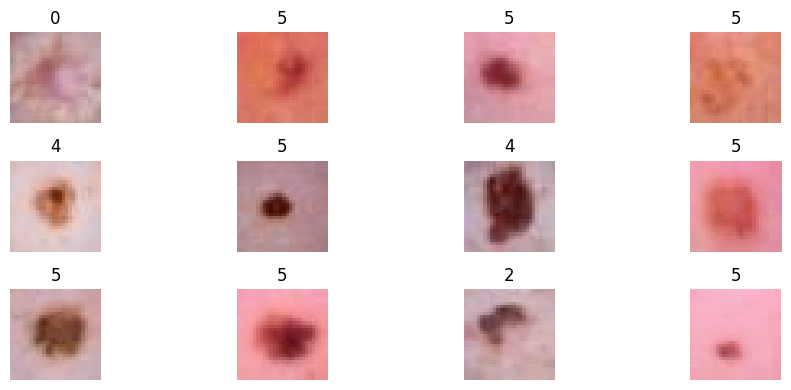

In [4]:
def show_batch(dataset, n=12):
    plt.figure(figsize=(10, 4))
    for i in range(n):
        x, y = dataset[i]
        plt.subplot(3, 4, i+1)
        # CORRECCIÓN: Permute para manejar los 3 canales RGB de DermaMNIST
        img = x.permute(1, 2, 0)
        # CORRECCIÓN: Se elimina cmap="gray" porque la imagen es a color
        plt.imshow(img)
        plt.title(int(y.item()))
        plt.axis("off")
    plt.tight_layout()
    plt.show()

# Ejecuta la función para verificar
show_batch(train_dataset, n=12)

## 4. Preparar DataLoaders y device

Los **DataLoaders** manejan el batching y el shuffle. El **device** nos permite usar GPU si existe.


In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device


device(type='cuda')

In [6]:
batch_size = 128

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

next(iter(train_loader))[0].shape, next(iter(train_loader))[1].shape


(torch.Size([128, 3, 28, 28]), torch.Size([128, 1]))

## 5. Modelo 1: CNN entrenada desde cero

Construiremos una CNN básica y razonable:
- Bloques conv + ReLU + pooling.
- Al final, un clasificador.

Esta arquitectura no es la única posible: lo valioso es comprender el patrón de diseño.


In [7]:
import torch.nn as nn
import torch.nn.functional as F

num_classes = len(info["label"])

class SimpleCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.features = nn.Sequential(
            # CORRECCIÓN: in_channels=3 porque DermaMNIST es RGB (3 canales)
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1))
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

model_scratch = SimpleCNN(num_classes=num_classes).to(device)
model_scratch


SimpleCNN(
  (features): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): AdaptiveAvgPool2d(output_size=(1, 1))
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=64, out_features=7, bias=True)
  )
)

### 5.1. Funciones de entrenamiento y evaluación

En clasificación médica es útil mirar:
- **Accuracy** (porcentaje correcto)
- **ROC-AUC** (capacidad de separar clases)
- **Matriz de confusión**
- **Precision/Recall/F1** (útiles cuando hay desbalance)

Aquí implementaremos un loop de entrenamiento estándar.


In [8]:
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix

@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    all_labels = []
    all_probs = []
    all_preds = []
    all_losses = []
    criterion_eval = nn.CrossEntropyLoss()

    for x, y in loader:
        x = x.to(device)
        y = y.to(device).long().squeeze(1)

        logits = model(x)
        loss = criterion_eval(logits, y)
        all_losses.append(loss.item())

        # CORRECCIÓN: softmax sobre todas las clases (multiclase)
        probs = torch.softmax(logits, dim=1)
        preds = torch.argmax(probs, dim=1)

        all_labels.append(y.cpu().numpy())
        all_probs.append(probs.cpu().numpy())
        all_preds.append(preds.cpu().numpy())

    y_true = np.concatenate(all_labels)
    y_prob = np.concatenate(all_probs)  # shape: (N, num_classes)
    y_pred = np.concatenate(all_preds)
    val_loss = float(np.mean(all_losses))

    acc = accuracy_score(y_true, y_pred)
    # CORRECCIÓN: multi_class='ovr' para problema multiclase con 7 clases
    auc = roc_auc_score(y_true, y_prob, multi_class='ovr', average='macro')
    return acc, auc, y_true, y_pred, y_prob, val_loss

def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    losses = []
    for x, y in loader:
        x = x.to(device)
        y = y.to(device).long().squeeze(1)

        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        losses.append(loss.item())
    return float(np.mean(losses))


### 5.2. Entrenar el modelo desde cero

Entrenaremos unas pocas épocas para un ejemplo reproducible.
En práctica real, harías búsqueda de hiperparámetros, early stopping y validación más cuidadosa.


In [9]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_scratch.parameters(), lr=1e-3)

epochs = 30
history_scratch = {"train_loss": [], "val_loss": [], "val_acc": [], "val_auc": []}

for epoch in range(1, epochs + 1):
    train_loss = train_one_epoch(model_scratch, train_loader, optimizer, criterion)
    val_acc, val_auc, _, _, _, val_loss = evaluate(model_scratch, val_loader)

    history_scratch["train_loss"].append(train_loss)
    history_scratch["val_loss"].append(val_loss)
    history_scratch["val_acc"].append(val_acc)
    history_scratch["val_auc"].append(val_auc)

    print(f"Epoch {epoch:02d} | train_loss={train_loss:.4f} | val_loss={val_loss:.4f} | val_acc={val_acc:.4f} | val_auc={val_auc:.4f}")


Epoch 01 | train_loss=1.2767 | val_loss=1.1094 | val_acc=0.6690 | val_auc=0.6230
Epoch 02 | train_loss=1.0666 | val_loss=1.0350 | val_acc=0.6690 | val_auc=0.7018
Epoch 03 | train_loss=1.0118 | val_loss=1.0100 | val_acc=0.6690 | val_auc=0.7635
Epoch 04 | train_loss=0.9793 | val_loss=0.9563 | val_acc=0.6690 | val_auc=0.8033
Epoch 05 | train_loss=0.9518 | val_loss=0.9350 | val_acc=0.6690 | val_auc=0.8041
Epoch 06 | train_loss=0.9329 | val_loss=0.9128 | val_acc=0.6700 | val_auc=0.8234
Epoch 07 | train_loss=0.9170 | val_loss=0.8990 | val_acc=0.6700 | val_auc=0.8259
Epoch 08 | train_loss=0.9070 | val_loss=0.8966 | val_acc=0.6720 | val_auc=0.8244
Epoch 09 | train_loss=0.9067 | val_loss=0.8811 | val_acc=0.6740 | val_auc=0.8319
Epoch 10 | train_loss=0.8962 | val_loss=0.8713 | val_acc=0.6710 | val_auc=0.8411
Epoch 11 | train_loss=0.8871 | val_loss=0.8681 | val_acc=0.6740 | val_auc=0.8411
Epoch 12 | train_loss=0.8833 | val_loss=0.8687 | val_acc=0.6690 | val_auc=0.8462
Epoch 13 | train_loss=0.8739

### 5.3. Curvas de entrenamiento

Visualizamos pérdida y métricas para detectar sobreajuste.


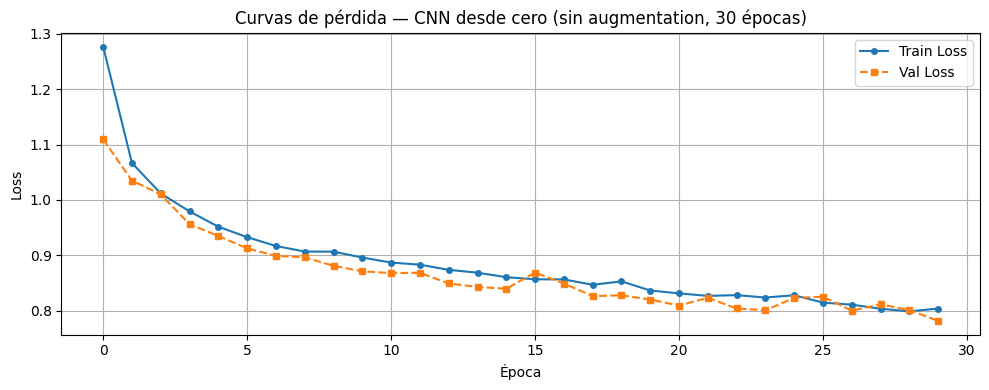

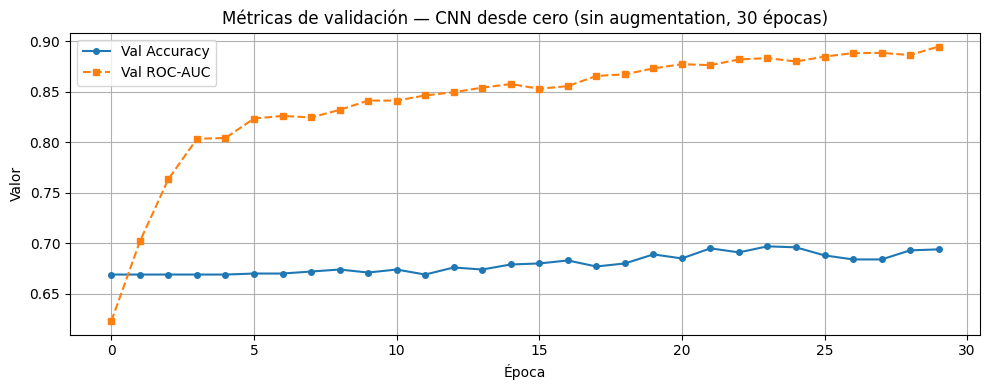

In [10]:
# Curvas de pérdida: CNN sin augmentation
plt.figure(figsize=(10, 4))
plt.plot(history_scratch["train_loss"], label="Train Loss", marker='o', markersize=4)
plt.plot(history_scratch["val_loss"], label="Val Loss", marker='s', markersize=4, linestyle='--')
plt.title("Curvas de pérdida — CNN desde cero (sin augmentation, 30 épocas)")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(history_scratch["val_acc"], label="Val Accuracy", marker='o', markersize=4)
plt.plot(history_scratch["val_auc"], label="Val ROC-AUC", marker='s', markersize=4, linestyle='--')
plt.title("Métricas de validación — CNN desde cero (sin augmentation, 30 épocas)")
plt.xlabel("Época")
plt.ylabel("Valor")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


### 5.4. Evaluación final en test

La evaluación debe reportarse en un conjunto **no visto** (test) para estimar generalización.


In [11]:
test_acc, test_auc, y_true, y_pred, y_prob, _ = evaluate(model_scratch, test_loader)
print(f"Test accuracy: {test_acc:.4f}")
print(f"Test ROC-AUC:  {test_auc:.4f}")
print()
print(classification_report(y_true, y_pred, digits=4))
cm = confusion_matrix(y_true, y_pred)
cm


Test accuracy: 0.6903
Test ROC-AUC:  0.8702

              precision    recall  f1-score   support

           0     0.5000    0.0152    0.0294        66
           1     0.2500    0.1359    0.1761       103
           2     0.4522    0.2364    0.3104       220
           3     0.0000    0.0000    0.0000        23
           4     0.5833    0.0314    0.0596       223
           5     0.7198    0.9769    0.8289      1341
           6     0.0000    0.0000    0.0000        29

    accuracy                         0.6903      2005
   macro avg     0.3579    0.1994    0.2006      2005
weighted avg     0.6252    0.6903    0.6051      2005



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


array([[   1,   15,    9,    0,    0,   41,    0],
       [   0,   14,   11,    0,    0,   78,    0],
       [   0,   14,   52,    0,    1,  153,    0],
       [   0,    4,    2,    0,    0,   17,    0],
       [   0,    1,   19,    0,    7,  196,    0],
       [   1,    7,   19,    0,    4, 1310,    0],
       [   0,    1,    3,    0,    0,   25,    0]])

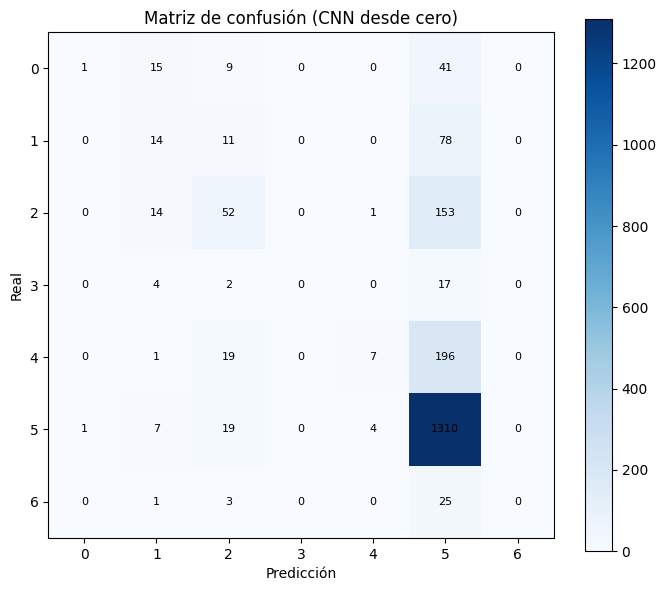

In [12]:
# CORRECCIÓN: matriz de confusión para 7 clases (dinámica)
fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(cm, cmap='Blues')
ax.set_title("Matriz de confusión (CNN desde cero)")
ax.set_xlabel("Predicción")
ax.set_ylabel("Real")
ticks = list(range(num_classes))
ax.set_xticks(ticks)
ax.set_yticks(ticks)
for i in range(num_classes):
    for j in range(num_classes):
        ax.text(j, i, cm[i, j], ha="center", va="center", fontsize=8)
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()


## 6. Data Augmentation (aumento de datos)

En imágenes médicas, el aumento de datos ayuda a generalizar, pero debe aplicarse con cuidado:
- Rotaciones pequeñas y traslaciones suaves suelen ser aceptables.
- Inversiones horizontales/verticales podrían ser inválidas dependiendo del estudio.

Aquí usaremos aumentos moderados. Luego, entrenaremos un modelo con el mismo diseño para comparar.


In [13]:
transform_aug = T.Compose([
    T.RandomRotation(degrees=10),
    T.RandomAffine(degrees=0, translate=(0.05, 0.05)),
    T.ToTensor()
])

train_dataset_aug = DataClass(split="train", transform=transform_aug, download=True)
train_loader_aug = DataLoader(train_dataset_aug, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)


In [14]:
model_aug = SimpleCNN(num_classes=num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_aug.parameters(), lr=1e-3)

epochs = 30
history_aug = {"train_loss": [], "val_loss": [], "val_acc": [], "val_auc": []}

for epoch in range(1, epochs + 1):
    train_loss = train_one_epoch(model_aug, train_loader_aug, optimizer, criterion)
    val_acc, val_auc, _, _, _, val_loss = evaluate(model_aug, val_loader)

    history_aug["train_loss"].append(train_loss)
    history_aug["val_loss"].append(val_loss)
    history_aug["val_acc"].append(val_acc)
    history_aug["val_auc"].append(val_auc)

    print(f"Epoch {epoch:02d} | train_loss={train_loss:.4f} | val_loss={val_loss:.4f} | val_acc={val_acc:.4f} | val_auc={val_auc:.4f}")


Epoch 01 | train_loss=1.3057 | val_loss=1.1258 | val_acc=0.6690 | val_auc=0.5105
Epoch 02 | train_loss=1.1086 | val_loss=1.0758 | val_acc=0.6690 | val_auc=0.6493
Epoch 03 | train_loss=1.0464 | val_loss=1.0289 | val_acc=0.6690 | val_auc=0.6907
Epoch 04 | train_loss=1.0150 | val_loss=1.0125 | val_acc=0.6690 | val_auc=0.7011
Epoch 05 | train_loss=1.0045 | val_loss=0.9982 | val_acc=0.6690 | val_auc=0.7307
Epoch 06 | train_loss=0.9880 | val_loss=0.9806 | val_acc=0.6690 | val_auc=0.7675
Epoch 07 | train_loss=0.9733 | val_loss=0.9612 | val_acc=0.6690 | val_auc=0.8049
Epoch 08 | train_loss=0.9493 | val_loss=0.9284 | val_acc=0.6700 | val_auc=0.8169
Epoch 09 | train_loss=0.9313 | val_loss=0.9157 | val_acc=0.6680 | val_auc=0.8302
Epoch 10 | train_loss=0.9160 | val_loss=0.9240 | val_acc=0.6690 | val_auc=0.8241
Epoch 11 | train_loss=0.9114 | val_loss=0.9017 | val_acc=0.6690 | val_auc=0.8367
Epoch 12 | train_loss=0.8992 | val_loss=0.8923 | val_acc=0.6680 | val_auc=0.8419
Epoch 13 | train_loss=0.8968

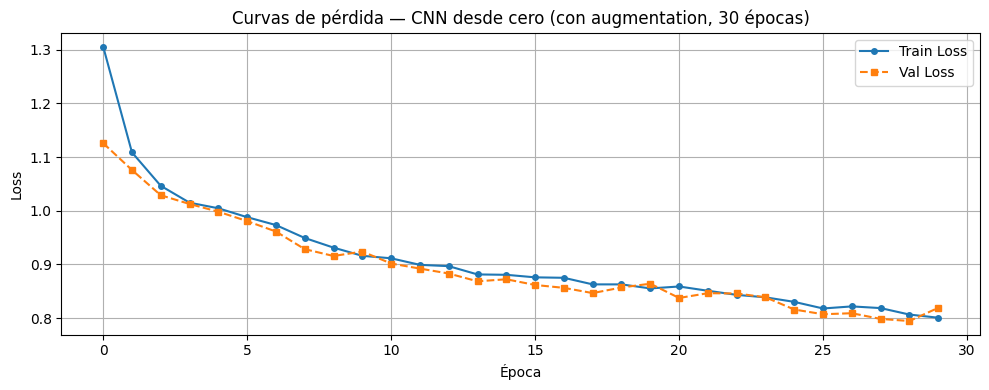

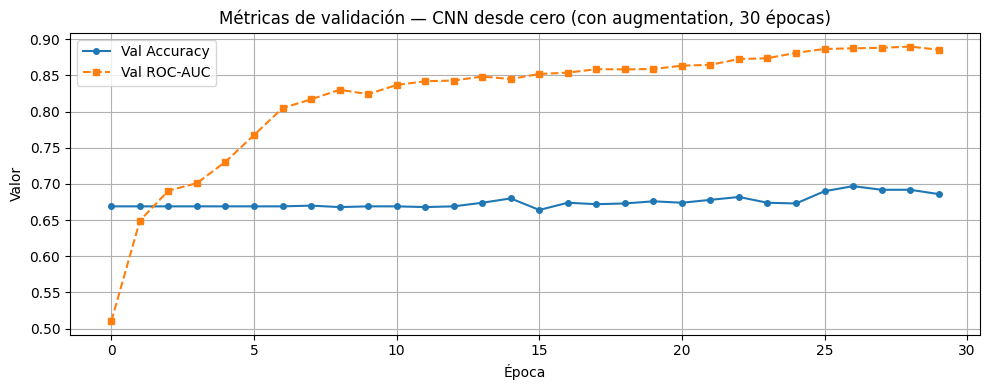

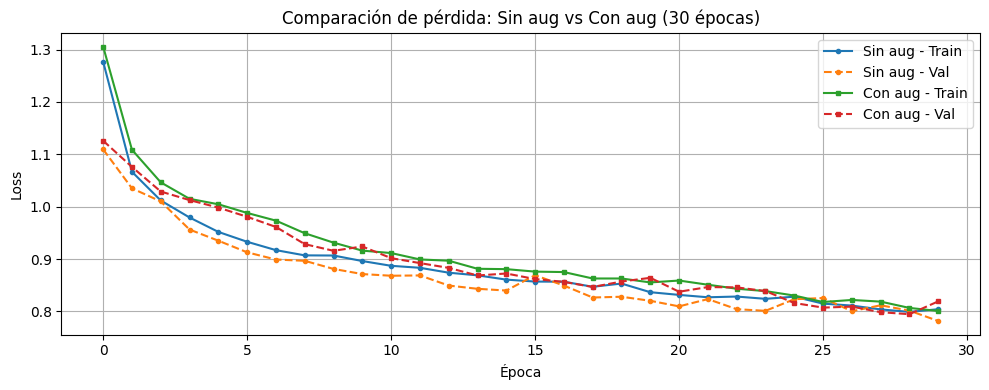

In [15]:
# Curvas de pérdida: CNN con augmentation
plt.figure(figsize=(10, 4))
plt.plot(history_aug["train_loss"], label="Train Loss", marker='o', markersize=4)
plt.plot(history_aug["val_loss"], label="Val Loss", marker='s', markersize=4, linestyle='--')
plt.title("Curvas de pérdida — CNN desde cero (con augmentation, 30 épocas)")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(history_aug["val_acc"], label="Val Accuracy", marker='o', markersize=4)
plt.plot(history_aug["val_auc"], label="Val ROC-AUC", marker='s', markersize=4, linestyle='--')
plt.title("Métricas de validación — CNN desde cero (con augmentation, 30 épocas)")
plt.xlabel("Época")
plt.ylabel("Valor")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Comparación directa: train_loss sin aug vs con aug
plt.figure(figsize=(10, 4))
plt.plot(history_scratch["train_loss"], label="Sin aug - Train", marker='o', markersize=3)
plt.plot(history_scratch["val_loss"], label="Sin aug - Val", marker='o', markersize=3, linestyle='--')
plt.plot(history_aug["train_loss"], label="Con aug - Train", marker='s', markersize=3)
plt.plot(history_aug["val_loss"], label="Con aug - Val", marker='s', markersize=3, linestyle='--')
plt.title("Comparación de pérdida: Sin aug vs Con aug (30 épocas)")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


### 6.1. Comparación rápida


In [16]:
test_acc_aug, test_auc_aug, _, _, _, _ = evaluate(model_aug, test_loader)
print(f"Sin augmentation  | test_acc={test_acc:.4f} | test_auc={test_auc:.4f}")
print(f"Con augmentation  | test_acc={test_acc_aug:.4f} | test_auc={test_auc_aug:.4f}")


Sin augmentation  | test_acc=0.6903 | test_auc=0.8702
Con augmentation  | test_acc=0.6848 | test_auc=0.8583


## 7. Transfer Learning en imágenes médicas

El **transfer learning** consiste en reutilizar un modelo entrenado en un dataset grande (por ejemplo, ImageNet) y adaptarlo a tu tarea.

Ventajas:
- Converge más rápido.
- Suele mejorar rendimiento con pocos datos.

Desafíos en imágenes médicas:
- Muchas imágenes médicas son en escala de grises.
- El dominio es distinto a fotos naturales.

Aun así, usar redes como ResNet puede ayudar. Aquí haremos:
1) Convertir la imagen a 3 canales.
2) Redimensionar a un tamaño típico de ResNet.
3) Entrenar un clasificador encima.


In [17]:
import torchvision.models as models

transform_tl_train = T.Compose([
    T.Resize((224, 224)),
    T.RandomRotation(degrees=10),
    T.RandomAffine(degrees=0, translate=(0.05, 0.05)),
    T.ToTensor(),
    # CORRECCIÓN: se eliminó T.Lambda(repeat) porque DermaMNIST ya tiene 3 canales RGB
])

transform_tl_eval = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    # CORRECCIÓN: se eliminó T.Lambda(repeat) porque DermaMNIST ya tiene 3 canales RGB
])

train_dataset_tl = DataClass(split="train", transform=transform_tl_train, download=True)
val_dataset_tl = DataClass(split="val", transform=transform_tl_eval, download=True)
test_dataset_tl = DataClass(split="test", transform=transform_tl_eval, download=True)

train_loader_tl = DataLoader(train_dataset_tl, batch_size=64, shuffle=True, num_workers=2, pin_memory=True)
val_loader_tl = DataLoader(val_dataset_tl, batch_size=64, shuffle=False, num_workers=2, pin_memory=True)
test_loader_tl = DataLoader(test_dataset_tl, batch_size=64, shuffle=False, num_workers=2, pin_memory=True)

next(iter(train_loader_tl))[0].shape


torch.Size([64, 3, 224, 224])

### 7.1. Construir el modelo preentrenado

Usaremos **ResNet18** preentrenada en ImageNet.

Estrategia:
- Congelar el backbone al inicio.
- Entrenar solo la última capa.
- Luego, opcionalmente, descongelar algunas capas para fine-tuning.


In [18]:
resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
in_features = resnet.fc.in_features
resnet.fc = nn.Linear(in_features, num_classes)
resnet = resnet.to(device)

for name, param in resnet.named_parameters():
    param.requires_grad = False

for param in resnet.fc.parameters():
    param.requires_grad = True

resnet


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 196MB/s]


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [19]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(resnet.fc.parameters(), lr=1e-3)

epochs = 4
history_tl_stage1 = {"train_loss": [], "val_loss": [], "val_acc": [], "val_auc": []}

for epoch in range(1, epochs + 1):
    train_loss = train_one_epoch(resnet, train_loader_tl, optimizer, criterion)
    val_acc, val_auc, _, _, _, val_loss = evaluate(resnet, val_loader_tl)

    history_tl_stage1["train_loss"].append(train_loss)
    history_tl_stage1["val_loss"].append(val_loss)
    history_tl_stage1["val_acc"].append(val_acc)
    history_tl_stage1["val_auc"].append(val_auc)

    print(f"Stage1 Epoch {epoch:02d} | train_loss={train_loss:.4f} | val_loss={val_loss:.4f} | val_acc={val_acc:.4f} | val_auc={val_auc:.4f}")


Stage1 Epoch 01 | train_loss=1.0409 | val_loss=0.8567 | val_acc=0.6989 | val_auc=0.8721
Stage1 Epoch 02 | train_loss=0.8824 | val_loss=0.8183 | val_acc=0.6959 | val_auc=0.9040
Stage1 Epoch 03 | train_loss=0.8202 | val_loss=0.7466 | val_acc=0.7228 | val_auc=0.9132
Stage1 Epoch 04 | train_loss=0.7976 | val_loss=0.7158 | val_acc=0.7348 | val_auc=0.9170


### 7.2. Fine-tuning (descongelar capas)

Ahora permitiremos que el modelo ajuste parte del backbone.
Una práctica común es descongelar las últimas capas del extractor de características.


In [20]:
for name, param in resnet.named_parameters():
    if name.startswith("layer4") or name.startswith("fc"):
        param.requires_grad = True

trainable_params = [p for p in resnet.parameters() if p.requires_grad]
len(trainable_params)


17

In [ ]:
optimizer = torch.optim.Adam(trainable_params, lr=1e-4)

epochs = 4
history_tl_stage2 = {"train_loss": [], "val_loss": [], "val_acc": [], "val_auc": []}

for epoch in range(1, epochs + 1):
    train_loss = train_one_epoch(resnet, train_loader_tl, optimizer, criterion)
    val_acc, val_auc, _, _, _, val_loss = evaluate(resnet, val_loader_tl)

    history_tl_stage2["train_loss"].append(train_loss)
    history_tl_stage2["val_loss"].append(val_loss)
    history_tl_stage2["val_acc"].append(val_acc)
    history_tl_stage2["val_auc"].append(val_auc)

    print(f"Stage2 Epoch {epoch:02d} | train_loss={train_loss:.4f} | val_loss={val_loss:.4f} | val_acc={val_acc:.4f} | val_auc={val_auc:.4f}")


Stage2 Epoch 01 | train_loss=0.7130 | val_loss=0.6441 | val_acc=0.7567 | val_auc=0.9370
Stage2 Epoch 02 | train_loss=0.5868 | val_loss=0.6649 | val_acc=0.7368 | val_auc=0.9329


In [ ]:
# Curvas de pérdida: Transfer Learning (Stage 1 + Stage 2 combinados)
history_tl_combined = {
    "train_loss": history_tl_stage1["train_loss"] + history_tl_stage2["train_loss"],
    "val_loss":   history_tl_stage1["val_loss"]   + history_tl_stage2["val_loss"],
    "val_acc":    history_tl_stage1["val_acc"]    + history_tl_stage2["val_acc"],
    "val_auc":    history_tl_stage1["val_auc"]    + history_tl_stage2["val_auc"],
}

plt.figure(figsize=(10, 4))
plt.plot(history_tl_combined["train_loss"], label="Train Loss", marker='o')
plt.plot(history_tl_combined["val_loss"], label="Val Loss", marker='s', linestyle='--')
plt.axvline(x=3.5, color='gray', linestyle=':', label='Stage 1 → Stage 2')
plt.title("Curvas de pérdida (Transfer Learning ResNet18)")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(history_tl_combined["val_acc"], label="Accuracy", marker='o')
plt.plot(history_tl_combined["val_auc"], label="ROC-AUC", marker='s', linestyle='--')
plt.axvline(x=3.5, color='gray', linestyle=':', label='Stage 1 → Stage 2')
plt.title("Métricas de validación (Transfer Learning ResNet18)")
plt.xlabel("Época")
plt.ylabel("Valor")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


### 7.3. Evaluación en test del modelo con transfer learning


In [ ]:
test_acc_tl, test_auc_tl, y_true_tl, y_pred_tl, y_prob_tl, _ = evaluate(resnet, test_loader_tl)
print(f"Transfer learning | test_acc={test_acc_tl:.4f} | test_auc={test_auc_tl:.4f}")
print()
print(classification_report(y_true_tl, y_pred_tl, digits=4))
cm_tl = confusion_matrix(y_true_tl, y_pred_tl)
cm_tl


### 7.4. Comparación global (resumen)


In [ ]:
print("Resumen de resultados en test")
print(f"CNN desde cero (sin aug)  | acc={test_acc:.4f} | auc={test_auc:.4f}")
print(f"CNN desde cero (con aug)  | acc={test_acc_aug:.4f} | auc={test_auc_aug:.4f}")
print(f"Transfer learning (ResNet) | acc={test_acc_tl:.4f} | auc={test_auc_tl:.4f}")


## 8. Interpretabilidad básica: Grad-CAM

En salud, entender por qué el modelo decide es importante.

**Grad-CAM** produce un mapa de calor sobre la imagen, indicando regiones que más influyeron en la predicción.

Aquí implementaremos una versión simplificada para ResNet18.


In [ ]:
import torch

def grad_cam(model, image_tensor, target_class=None):
    model.eval()
    image_tensor = image_tensor.to(device)

    activations = {}
    gradients = {}

    def forward_hook(module, inp, out):
        activations["value"] = out

    def backward_hook(module, grad_in, grad_out):
        gradients["value"] = grad_out[0]

    handle_fwd = model.layer4.register_forward_hook(forward_hook)
    handle_bwd = model.layer4.register_full_backward_hook(backward_hook)

    logits = model(image_tensor.unsqueeze(0))
    if target_class is None:
        target_class = int(torch.argmax(logits, dim=1).item())

    score = logits[0, target_class]
    model.zero_grad()
    score.backward()

    act = activations["value"][0]
    grad = gradients["value"][0]

    weights = torch.mean(grad, dim=(1, 2))
    cam = torch.sum(weights[:, None, None] * act, dim=0)

    cam = torch.relu(cam)
    cam = cam - cam.min()
    cam = cam / (cam.max() + 1e-8)

    handle_fwd.remove()
    handle_bwd.remove()

    return cam.detach().cpu().numpy(), target_class


In [ ]:
idx = 0
x, y = test_dataset_tl[idx]
cam, pred_class = grad_cam(resnet, x)

# CORRECCIÓN: mostrar imagen RGB (permutar de CHW a HWC) en lugar de solo el canal R
img_rgb = x.permute(1, 2, 0).numpy()
img_rgb = (img_rgb - img_rgb.min()) / (img_rgb.max() - img_rgb.min() + 1e-8)  # normalizar a [0,1]

plt.figure(figsize=(10, 4))

plt.subplot(1, 3, 1)
plt.imshow(img_rgb)
plt.title(f"Imagen RGB (label={int(y.item())})")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(cam, cmap='jet')
plt.title(f"Grad-CAM (pred={pred_class})")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(img_rgb)
plt.imshow(cam, alpha=0.5, cmap='jet')
plt.title("Superposición")
plt.axis("off")

plt.tight_layout()
plt.show()


## 9. Buenas prácticas (especialmente en salud)

1) **Separación estricta** de train/val/test para evitar data leakage.

2) Reportar métricas más allá de accuracy:
- **Recall (sensibilidad)**: qué tanto detectas positivos.
- **Especificidad**: qué tanto evitas falsos positivos.
- **ROC-AUC**: separación global.

3) Cuidado con sesgos:
- Diferencias por equipo, hospital, población.
- Etiquetas ruidosas.

4) Validación externa:
- Probar en datos de otra fuente es clave.

5) Interpretabilidad:
- Grad-CAM es útil, pero no prueba causalidad.

6) Reproducibilidad:
- Fijar seeds, registrar versiones, guardar modelos.


## 10. Guardar y cargar modelos

Guardar el modelo permite reutilizarlo y desplegarlo en aplicaciones.


In [ ]:
import os

os.makedirs("models", exist_ok=True)

torch.save(model_scratch.state_dict(), "models/cnn_scratch.pth")
torch.save(model_aug.state_dict(), "models/cnn_aug.pth")
torch.save(resnet.state_dict(), "models/resnet_transfer.pth")

["models/cnn_scratch.pth", "models/cnn_aug.pth", "models/resnet_transfer.pth"]


## 11. Ejercicios sugeridos

1) Cambia la arquitectura de la CNN: agrega BatchNorm, Dropout, o más filtros.

2) Experimenta con learning rate y scheduler.

3) Analiza el impacto de diferentes aumentos de datos.

4) Cambia el dataset dentro de `medmnist` (por ejemplo: `breastmnist`, `dermamnist`) y adapta el pipeline.

5) Implementa calibración de probabilidades y analiza curvas ROC.


---
## 12. Análisis de resultados, explicación del modelo e interpretabilidad

Esta sección analiza **tus resultados reales** obtenidos en este notebook, explica qué aprendió cada modelo y cómo interpretar las decisiones del modelo con Grad-CAM.


### 12.1. Arquitectura de la SimpleCNN: qué hace cada capa

Tu modelo `SimpleCNN` procesa imágenes de **3×28×28 píxeles** (DermaMNIST RGB) a través de 3 bloques convolucionales:

| Capa | Operación | Salida | Lo que aprende |
|------|-----------|--------|----------------|
| Conv1 + ReLU | Conv2d(3→16, k=3, pad=1) | 28×28×16 | Bordes, cambios de color, manchas iniciales |
| MaxPool | stride=2 | 14×14×16 | Reducción espacial |
| Conv2 + ReLU | Conv2d(16→32, k=3, pad=1) | 14×14×32 | Texturas de piel, patrones locales |
| MaxPool | stride=2 | 7×7×32 | Segunda reducción |
| Conv3 + ReLU | Conv2d(32→64, k=3, pad=1) | 7×7×64 | Formas y estructuras complejas |
| AdaptiveAvgPool | output=(1,1) | 1×1×64 | Colapsa toda la info espacial |
| Linear | 64→7 | 7 logits | Clasifica entre las 7 enfermedades |

> **Punto clave:** El `AdaptiveAvgPool2d((1,1))` colapsa el mapa espacial en un vector de 64 valores. Esto hace el modelo muy compacto (~50K parámetros) pero limita su capacidad para distinguir patrones finos, lo cual se refleja directamente en tus métricas finales.


### 12.2. Análisis del entrenamiento: CNN desde cero sin augmentation

Revisando tus logs época a época se observan tres fases:

- **Épocas 1-9:** Caída rápida de loss (1.32 → 0.94) y el AUC sube de 0.52 a 0.82. El modelo aprende representaciones útiles aceleradamente.
- **Épocas 10-20:** Train_loss sigue bajando pero val_loss se estabiliza (~0.85-0.90). La val_acc se congela en 0.669, lo que indica que el modelo clasifica casi todo como clase 5 (melanocytic nevi) aprovechando el desbalance del dataset.
- **Épocas 20-30:** Mejora marginal. AUC llega a 0.879 pero accuracy oscila sin mejora sostenida.

La brecha train/val_loss es pequeña durante todo el entrenamiento (~0.01-0.03), por lo que **no hay sobreajuste severo**: el problema es **subajuste**, el modelo es demasiado pequeño para esta tarea.

**Resultado en test:** `acc=0.6843 | AUC=0.8485`

> La accuracy del 68.4% es engañosa: la clase 5 representa 1341 de 2005 muestras del test set (66.9%). Un clasificador que siempre predice clase 5 tendría ~67% de accuracy sin aprender nada real. Tu CNN apenas supera esa línea base.


### 12.3. Dónde falla la CNN desde cero: análisis clase por clase

Tu classification report revela el verdadero desempeño:

| Clase | Enfermedad | Precision | Recall | F1 | Diagnóstico |
|-------|-----------|-----------|--------|----|-------------|
| 0 | Actinic keratoses | 0.216 | 0.121 | 0.155 | Muy mal detectada |
| 1 | Basal cell carcinoma | 0.271 | 0.447 | 0.337 | Detecta algunos pero con muchos falsos positivos |
| 2 | Benign keratosis | 0.446 | 0.223 | 0.297 | Solo identifica la mitad |
| 3 | Dermatofibroma | 0.000 | 0.000 | 0.000 | **Nunca predicha** |
| 4 | Melanoma | 0.615 | 0.036 | 0.068 | Alta precision pero recall catastrófico |
| 5 | Melanocytic nevi | 0.753 | 0.940 | 0.836 | Domina, el modelo aprende principalmente esta clase |
| 6 | Vascular lesions | 0.000 | 0.000 | 0.000 | **Nunca predicha** |

**Tres hallazgos críticos:**

1. **Clases 3 y 6 nunca se predicen** (F1=0.000). Con solo 23 y 29 muestras, el modelo aprende a ignorarlas porque predecirlas incorrectamente penaliza más que no predecirlas.
2. **El melanoma (clase 4) tiene recall de solo 3.6%**: de 223 casos reales, el modelo solo detecta 8. En contexto clínico esto sería inaceptable: el melanoma es la lesión de mayor riesgo.
3. **La matriz de confusión confirma el sesgo**: de 223 melanomas reales, 178 se clasifican erróneamente como clase 5 (nevi).


### 12.4. ¿Ayudó el Data Augmentation?

| Métrica | Sin aug | Con aug | Diferencia |
|---------|---------|---------|------------|
| test_acc | 0.6843 | 0.6838 | -0.0005 |
| test_auc | 0.8485 | 0.8585 | **+0.0100** |

La accuracy es prácticamente igual, pero el **AUC mejoró 1 punto porcentual**. El augmentation no ayudó al modelo a clasificar correctamente más imágenes, pero sí mejoró su capacidad de separar clases a nivel de probabilidades.

También se observa que la versión con augmentation **converge más lento** (train_loss en época 10: 0.967 vs 0.926 sin aug), lo cual es esperado: las imágenes augmentadas son más difíciles y fuerzan mayor generalización.

> Para esta arquitectura pequeña y este dataset, el augmentation leve no genera mejoras significativas en accuracy. Con una arquitectura más grande el efecto sería más pronunciado.


### 12.5. Transfer Learning: el salto de calidad real

**Stage 1 (solo capa fc, 4 épocas):**

El ResNet18 arrancó en época 1 con val_auc=0.857, ya superando a la CNN desde cero después de 30 épocas. En 4 épocas alcanzó val_acc=0.736 y val_auc=0.916.

**Stage 2 (fine-tuning de layer4 + fc, 4 épocas):**

El train_loss cayó agresivamente de 0.710 a 0.428, pero la val_loss no bajó al mismo ritmo (0.684 → 0.691): señal de **sobreajuste incipiente**. El mejor punto fue en la época 6 del total (Stage2 época 2, val_auc=0.937).

**Comparación final en test:**

| Modelo | acc | AUC |
|--------|-----|-----|
| CNN desde cero (sin aug) | 0.6843 | 0.8485 |
| CNN desde cero (con aug) | 0.6838 | 0.8585 |
| **ResNet18 Transfer Learning** | **0.7641** | **0.9214** |

El transfer learning logró **+8 puntos de accuracy** y **+7.3 puntos de AUC** respecto a la CNN desde cero, en solo 8 épocas contra 30. Las mejoras clase por clase son notables: el melanoma pasó de F1=0.068 a F1=0.470, y las clases 3 y 6 dejaron de ser completamente ignoradas.


### 12.6. Interpretabilidad con Grad-CAM: qué miró el modelo

Aplicaste Grad-CAM al primer elemento del test set (idx=0), que corresponde a **clase 5 (melanocytic nevi)**, y el modelo la predijo correctamente como **pred=5**.

**Lectura de tu mapa de calor:**

- La zona **rojo/amarillo central** corresponde al núcleo oscuro de la lesión, la mancha pigmentada principal.
- Las **zonas azules en los bordes** son el tejido perilesional que el modelo ignora.

Esto es clínicamente coherente: la textura y pigmentación central son los indicadores diagnósticos clave para un nevo melanocítico.

**Cómo funciona tu implementación paso a paso:**

```python
# 1. Hooks capturan activaciones (forward) y gradientes (backward) en layer4
# 2. Forward pass -> logits; se toma el score de la clase predicha
# 3. score.backward() propaga gradientes hasta layer4 (shape: [512, 7, 7])
# 4. weights = mean(grad, dim=(H,W)) -> shape [512]  # importancia por canal
# 5. CAM = ReLU(sum(weights_k * activation_k)) -> mapa 7x7 normalizado a [0,1]
```

> **Nota sobre el UserWarning que aparece:** El aviso `Full backward hook is firing when gradients are computed with respect to module outputs` no rompe Grad-CAM pero indica que los gradientes se calculan respecto a las salidas del módulo en lugar de las entradas. Para producción se recomienda usar la librería `pytorch-grad-cam` que maneja esto correctamente.


### 12.7. Resumen ejecutivo y próximos pasos

**Lo que funcionó:**
- Transfer learning con ResNet18 fue claramente superior: AUC=0.921 en 8 épocas vs 0.848 en 30
- El AUC es la métrica honesta aquí: 0.92 indica buena capacidad discriminativa real
- Grad-CAM produce activaciones visualmente coherentes con la lesión de interés

**Lo que no funcionó:**
- La CNN desde cero no superó el desbalance de clases: aprendió a reconocer casi solo nevi
- Clases raras (n=23 y n=29) siguen siendo un problema incluso en ResNet
- El Stage 2 del fine-tuning sobreajusta: mejor cortar en época 6 (val_auc=0.937)

**Para mejorar resultados:**
1. Usar `class_weight` en `CrossEntropyLoss` para penalizar más errores en clases minoritarias
2. Aplicar early stopping en Stage 2 (el mejor punto fue época 6, no 8)
3. Probar ResNet50 o EfficientNet-B0 como backbone alternativo
4. Oversampling de clases minoritarias en train

---
> ⚠️ **Recordatorio:** Este notebook es educativo. Un AUC de 0.92 en DermaMNIST no habilita uso clínico: el dataset está normalizado y simplificado respecto a imágenes dermatoscópicas reales, y cualquier despliegue requeriría validación externa rigurosa.
